# Cis-/trans- interactions calculation

### Load Hi-C cool files (250kb resolution)

In [1]:
import cooltools
import cooler
from tqdm import tqdm
from os.path import basename, splitext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections.abc import Iterable
import bioframe
import gc
import subprocess
import itertools
import pysam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import seaborn as sns

In [2]:
wt_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_250k/balsampled_Adult_250k.cool')
old_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_250k/balsampled_Old_250k.cool')
ko_clr = cooler.Cooler('/tank/projects/kashuk_sirt6_hic/bal_comb_250k/balsampled_S6-KO_250k.cool')

CLRS = [wt_clr, old_clr, ko_clr]
LBLS = ['Adult', 'Old', 'S6-KO']

### Define the function to compute cis- and trans- contacts

In [3]:
def compute_cis_trans(hiclist, dropdiag=2, resolution=100000, stable=True, normalized=False):
    """
    This function returns a dictionary where keys are names of Hi-C matrices
    and values are matrices of cis-trans contact sums.
    
    hiclist :: [str] - list of paths to .mcool files
    dropdiag :: int - number of diags to drop (main diagonal counts from 1)
    resolution :: int - desired resolution for Hi-C matrix
    stable :: bool - whether to add 1 to contact sums matrix (for numerical 
                     stability at logarithm computation)
    normalized :: bool - whether to normalize matrix with a total sum of contacts
    """
    interchrom = {}
    for clr in CLRS:
        
        
        sizes = np.array(clr.chromsizes.values) / resolution #compute normalization matrix
        #norm = np.outer(sizes, sizes)

        pix = clr.pixels()[:]
        pix_no_diag = pix[pix.bin2_id >= pix.bin1_id + dropdiag] #delete m first diagonals
        bins = clr.bins()[:].drop(['start', 'end'], axis = 1)

        cis_trans = np.asarray(
                    pix_no_diag.merge(bins, left_on='bin1_id', right_index=True).\
                                merge(bins, left_on='bin2_id', right_index=True).\
                                groupby(['chrom_x', 'chrom_y']).sum().\
                                unstack(fill_value=0)['count']) #convert to square matrix

        cis_trans = cis_trans + cis_trans.T - np.diag(np.diag(cis_trans))
        if stable:
            cis_trans += 1
        if normalized:
            fullsum = np.nansum(cis_trans)
            if fullsum == 0.:
                print('Drop %s due to zero contact sum' % path)
                continue
            cis_trans = cis_trans / fullsum * 2 * 1_000_000 #scale by constant
        result = cis_trans #/ norm
        interchrom[splitext(basename(clr.filename))[0]] = result
    return interchrom

In [4]:
interactions = compute_cis_trans(CLRS, dropdiag=0, resolution=250_000, stable=True, normalized=False)
interactions = dict(zip(['_'.join(k.split('_')[1:2]) for k in interactions.keys()], interactions.values()))

### Analyze the ratio of interactions and collect data for plotting

In [5]:
pairs = [('Old','Adult'), ('S6-KO','Adult')]
statvals_cis = pd.DataFrame()
statvals_trs = pd.DataFrame()

for pair in pairs:
    map1 = interactions[pair[0]]
    map2 = interactions[pair[1]]
    m = map1 / map2
    
    # For boxplots
    statvals_cis[pair[0] + '/' + pair[1]] = m.diagonal()
    statvals_trs[pair[0] + '/' + pair[1]] = m[np.triu_indices_from(m, k=1)]
    cis = pd.melt(statvals_cis)
    trans = pd.melt(statvals_trs)

In [6]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


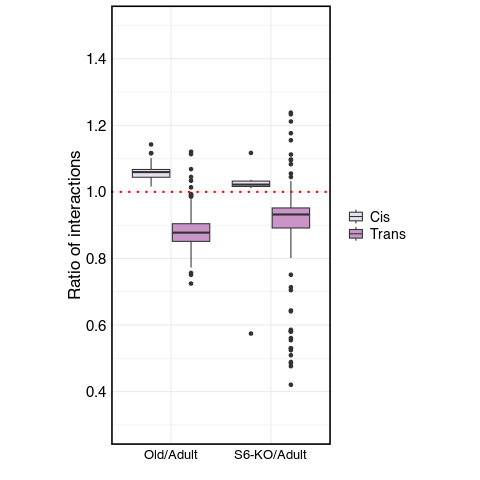

In [8]:
%%R
library(reticulate)
library(ggplot2)
library(scales)

cis <- reticulate::py_eval("cis")
trans <- reticulate::py_eval("trans")
cis$type <- 'Cis'
trans$type <- 'Trans'
df <- rbind(cis, trans)
df$variable <- factor(df$variable, levels=c('Old/Adult', 'S6-KO/Adult'))

p <- ggplot(df, aes(variable, value)) +
  geom_boxplot(position = position_dodge(0.8), aes(fill = type)) +
  theme_minimal() +
  geom_hline(yintercept=1, linetype='dotted', col = 'red', size=1) +
  xlab("") + ylab("Ratio of interactions") +
  scale_fill_brewer(palette="PuRd") +
  scale_y_continuous(
    limits = c(0.3, 1.5),
    breaks = pretty_breaks(n = 5)
  ) +
  theme(axis.text.x = element_text(size = 13, colour = 'black'),
        axis.text.y = element_text(size = 15, colour = 'black'),
        axis.title.y = element_text(size = 17, colour='black'),
        legend.title = element_blank(),
        legend.text = element_text(size=14),
        panel.border = element_rect(colour = "black", fill=NA, size=1.5),
        aspect.ratio = 2/1)

print(p)

In [13]:
cis_interactions = pd.DataFrame()
trans_interactions = pd.DataFrame()

conditions = ['Old', 'Adult', 'S6-KO']

for condition in conditions:
    mat = interactions[condition]
    
    # Extract cis interactions (diagonal elements)
    cis_interactions[condition] = mat.diagonal()
    
    # Extract trans interactions (upper triangle excluding diagonal)
    trans_interactions[condition] = mat[np.triu_indices_from(mat, k=1)]

cis_melted = pd.melt(cis_interactions)
trans_melted = pd.melt(trans_interactions)

In [28]:
%%R

cis <- reticulate::py_eval("cis_melted")
trans <- reticulate::py_eval("trans_melted")
cis$type <- 'Cis'
trans$type <- 'Trans'

cis_adult <- subset(cis, variable == 'Adult')
cis_old <- subset(cis, variable == 'Old')
cis_s6_ko <- subset(cis, variable == 'S6-KO') 

trans_adult <- subset(trans, variable == 'Adult')
trans_old <- subset(trans, variable == 'Old')
trans_s6_ko <- subset(trans, variable == 'S6-KO')

comparisons <- list(
  c('Adult', 'Old'),
  c('Adult', 'S6_KO')  
)

results <- data.frame()

for (type in c('cis', 'trans')) {
  for (pair in comparisons) {
    cond1 <- pair[1]
    cond2 <- pair[2]

    lookup_cond1 <- tolower(cond1)
    lookup_cond2 <- tolower(gsub("-", "_", cond2))
    
    data1 <- get(paste0(type, "_", lookup_cond1))
    data2 <- get(paste0(type, "_", lookup_cond2))
    
    test_result <- wilcox.test(data1$value, data2$value, paired = TRUE)
    
    results <- rbind(results, data.frame(
      comparison = paste(gsub("_", "-", cond1), "vs", gsub("_", "-", cond2)), 
      type = type,
      p.value = test_result$p.value,
      statistic = test_result$statistic,
      stringsAsFactors = FALSE
    ))
  }
}

print(results)

       comparison  type      p.value statistic
V    Adult vs Old   cis 9.536743e-07         0
V1 Adult vs S6-KO   cis 1.907349e-06         1
V2   Adult vs Old trans 1.974205e-35     22030
V3 Adult vs S6-KO trans 7.532136e-27     20536
